**Hypothesis**. We are considering a redesign of the subscription screen, on which we offer a subscription at the standard price of $4.99, but specify that this represents a 50% discount on the subscription price.  It is expected that an awareness of the uniqueness of the offer and  the desire to save money on the subscription will encourage users to purchase the subscription more actively.

During the trial period, the app was installed by **19,998** users.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Paths
DATA_PATH = Path("../data/ab_test_data.csv")
PLOT_PATH = Path("../plots/conversion_rate.png")

alpha = 0.05

# Load data
df_test_results = pd.read_csv(DATA_PATH)

print(df_test_results.info())
display(df_test_results.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19998 entries, 0 to 19997
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     19998 non-null  object
 1   timestamp   19998 non-null  object
 2   test_group  19998 non-null  object
 3   conversion  19998 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 625.1+ KB
None


,user_id,timestamp,test_group,conversion
0,7f6833e6-1141-4f20-b4b2-f1e31019b1fd,2023-07-04 04:40:55.848109,a,0
1,e6a6e960-d3f3-4074-a516-ba1e609b211e,2023-07-06 00:26:45.486187,b,0
2,4d3fbfa5-6847-410a-bac2-477f01d5f400,2023-07-10 20:24:33.639464,b,0
3,361457d9-a044-48f7-981c-d67dc3861679,2023-07-20 07:04:49.957013,b,0
4,285cd63d-7d03-427f-a062-1fa2dd2e77d6,2023-07-19 23:27:50.116680,b,0


Once the app had been installed, users were split into two groups. Some of them – specifically, test group **(B)** – were shown an experimental screen offering a 50% discount.

In [2]:
# Check whether each user appears only once
assert df_test_results["user_id"].is_unique

# Convert timestamp to datetime
df_test_results["timestamp"] = pd.to_datetime(
    df_test_results["timestamp"].astype(str).str[:10]
)

# Chronological data
start_date = df_test_results["timestamp"].min()
end_date = df_test_results["timestamp"].max()
how_long = (end_date - start_date).days + 1

print(f"Test start date: {start_date.date()}")
print(f"Test end date: {end_date.date()}")
print(f"Test duration: {how_long} days")

Test start date: 2023-07-03
Test end date: 2023-07-25
Test duration: 23 days


**The sizes** of groups A and B and, respectively, the **conversion rate** from install to payment during the experiment were as follows:

In [10]:
# Calculated conversions
group_stats = df_test_results.groupby("test_group").agg(
    users_qty=("user_id", "count"),
    converters_qty=("conversion", "sum"),
    conversion_rate=("conversion", "mean")
)

group_a_users = group_stats.loc["a", "users_qty"]
group_a_converters = group_stats.loc["a", "converters_qty"]
group_a_rate = group_stats.loc["a", "conversion_rate"]

group_b_users = group_stats.loc["b", "users_qty"]
group_b_converters = group_stats.loc["b", "converters_qty"]
group_b_rate = group_stats.loc["b", "conversion_rate"]

print(group_stats)

relative_lift = (group_b_rate - group_a_rate) / group_a_rate

print(f'The size of test group A was: {group_a_users} users; The size of test group B was: {group_b_users} users', "\n")
print(f'The number of Group A converters was: {group_a_converters} users; The number of Group B converters was: {group_b_converters} users', "\n")
print(f'The conversion factor in Group A is: {group_a_rate:.2%}; The conversion factor in Group B is: {group_b_rate:.2%}')

            users_qty  converters_qty  conversion_rate
test_group                                            
a               10013             611         0.061021
b                9985             889         0.089034
The size of test group A was: 10013 users; The size of test group B was: 9985 users 

The number of Group A converters was: 611 users; The number of Group B converters was: 889 users 

The conversion factor in Group A is: 6.10%; The conversion factor in Group B is: 8.90%


So, the conversion rate in test group B is **higher** than in control group A by **46%**. To determine whether this increase in conversion is statistically significant, we will compare the **p-value and alpha** – the acceptable probability of incorrectly rejecting the null hypothesis, which was set at **5%** at the start of the test.

Let’s calculate the **Student’s t-test** for our two samples **A** and **B**

In [4]:
# t-test
conversion_a = df_test_results.loc[
    df_test_results["test_group"] == "a", "conversion"
]

conversion_b = df_test_results.loc[
    df_test_results["test_group"] == "b", "conversion"
]

statistic, pvalue = stats.ttest_ind(
    conversion_a,
    conversion_b,
    alternative="less"
)

print(f"t-statistic: {statistic:.2f}")
print(f"p-value: {pvalue:.3e}")

if pvalue < alpha:
    print(
        f"p-value < alpha ({alpha}). "
        "Reject the null hypothesis."
    )
else:
    print(
        f"p-value >= alpha ({alpha}). "
        "Fail to reject the null hypothesis."
    )

t-statistic: -7.53
p-value: 2.646e-14
p-value < alpha (0.05). Reject the null hypothesis.


In [5]:
# χ²test
contingency_table = pd.crosstab(
    df_test_results["test_group"],
    df_test_results["conversion"]
)

chi2_statistic, chi2_pvalue, dof, expected = chi2_contingency(
    contingency_table,
    correction=False
)

print("Contingency table:")
print(contingency_table)

print(f"\nChi-square statistic: {chi2_statistic:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {chi2_pvalue:.3e}")

if chi2_pvalue < alpha:
    print(
        f"p-value < alpha ({alpha}). "
        "Reject the null hypothesis of independence."
    )
else:
    print(
        f"p-value >= alpha ({alpha}). "
        "Fail to reject the null hypothesis of independence."
    )

Contingency table:
conversion     0    1
test_group           
a           9402  611
b           9096  889

Chi-square statistic: 56.55
Degrees of freedom: 1
p-value: 5.491e-14
p-value < alpha (0.05). Reject the null hypothesis of independence.


**The interval** within which the relative increase in conversion rate lies, with a 95% confidence level

In [6]:
# confidence interval
mean_a = np.mean(conversion_a)
mean_b = np.mean(conversion_b)

std_a = np.std(conversion_a, ddof=1)
std_b = np.std(conversion_b, ddof=1)

n_a = len(conversion_a)
n_b = len(conversion_b)

se_diff = np.sqrt(
    (std_a**2 / n_a) +
    (std_b**2 / n_b)
)

df = min(n_a - 1, n_b - 1)
t_critical = stats.t.ppf(1 - alpha / 2, df)

ci_lower = (mean_b - mean_a) - t_critical * se_diff
ci_upper = (mean_b - mean_a) + t_critical * se_diff

ci_lower_relative = ci_lower / mean_a
ci_upper_relative = ci_upper / mean_a

print(
    "95% CI for relative conversion lift: "
    f"[{ci_lower_relative:.1%}, {ci_upper_relative:.1%}]"
)

95% CI for relative conversion lift: [34.0%, 57.9%]


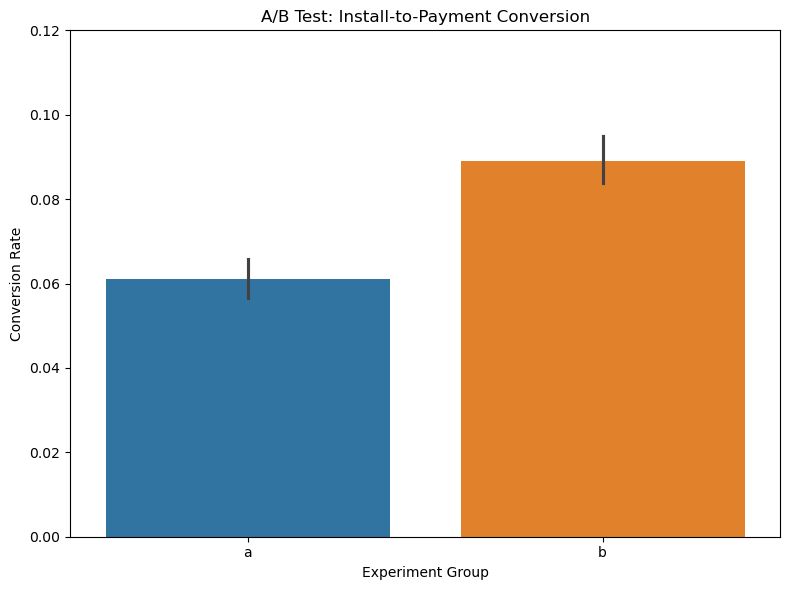

In [7]:
# chart
# Create output directory if needed
PLOT_PATH.parent.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 6))

sns.barplot(
    data=df_test_results,
    x="test_group",
    y="conversion",
    hue="test_group",
    errorbar=("ci", 95),
    legend=False
)

plt.title("A/B Test: Install-to-Payment Conversion")
plt.xlabel("Experiment Group")
plt.ylabel("Conversion Rate")
plt.ylim(0, 0.12)
plt.tight_layout()

plt.savefig(PLOT_PATH, dpi=150, bbox_inches="tight")
plt.show()